# Representation Theory Project: $\mathfrak{sl}_2$ and $\mathfrak{sl}_3$

This project arises from the need to firmly understand the topics covered in Maria's 601 course regarding the Lie algebras $\mathfrak{sl}_2$ and $\mathfrak{sl}_3$.

The objective of the project is to understand the definition of these representations, how to handle them, their properties, and see what combinatorics we can use to describe them further.


In [56]:
# Create the Lie algebra sl_2 and its standard defining representation using Sage's LieAlgebra
sl2 = LieAlgebra(QQ, cartan_type=['A', 1], representation='matrix')

# For Cartan type A1, the generators are returned in order: E, F, H.
E, F, H = sl2.gens()

print("Generator E:\n", E.matrix())
print("Generator F:\n", F.matrix())
print("Generator H:\n", H.matrix())

print("\n--- Verifying Fundamental Relations in the 2x2 standard representation ---")
print("[E, E] == 0 :", sl2[E, E] == sl2.zero())
print("[E, F] == H :", sl2[E, F] == H)
print("[H, E] == 2E:", sl2[H, E] == 2*E)
print("[H, F] == -2F:", sl2[H, F] == -2*F)


Generator E:
 [0 1]
[0 0]
Generator F:
 [0 0]
[1 0]
Generator H:
 [ 1  0]
[ 0 -1]

--- Verifying Fundamental Relations in the 2x2 standard representation ---
[E, E] == 0 : True
[E, F] == H : True
[H, E] == 2E: True
[H, F] == -2F: True


## 1.1 Classification and Realization of Irreducible Representations

Following Fulton & Harris (Claim 11.5 - 11.8), we can classify all finite-dimensional irreducible representations of $\mathfrak{sl}_2$ based on the action of $H$.

By writing down a basis for an arbitrary irreducible representation $V$ and examining where $H$, $E$ (F&H's $X$), and $F$ (F&H's $Y$) map each vector, we reach a powerful conclusion:
1. **Highest Weight**: Every irreducible representation $V$ is completely determined by a single non-negative integer $n$. We call this representation $V^{(n)}$.
2. **Dimension**: The dimension of $V^{(n)}$ is $n + 1$.
3. **Weight Spaces**: The eigenvalues of $H$ on $V^{(n)}$ (the "weights") form a contiguous string of integers differing by 2 and symmetric about the origin:
   $$ n, n - 2, \dots, -n + 2, -n $$
4. **Multiplicity-Free**: Every eigenspace $V_{\alpha}$ of $H$ is exactly **1-dimensional**.

*Useful Corollary*: Any representation $V$ of $\mathfrak{sl}_2$ where the eigenvalues of $H$ share the same parity and occur with multiplicity 1 is necessarily irreducible!

### Realizing $V^{(n)}$ as Symmetric Powers

We can explicitly construct $V^{(n)}$ for any $n$ using the **standard representation** $V \cong \mathbb{C}^2$. 

Let $x$ and $y$ be the standard basis for $\mathbb{C}^2$, such that $H(x) = x$ and $H(y) = -y$. The generators act as differential operators:
$$ E = x\partial_y, \quad F = y\partial_x, \quad H = x\partial_x - y\partial_y $$

The $n$-th symmetric power $\text{Sym}^n(V)$ has a natural basis of dimension $n+1$:
$$ \{x^n, x^{n-1}y, x^{n-2}y^2, \dots, y^n\} $$

Applying our operators to a general basis vector $v_k = x^{n-k}y^k$ (where $0 \le k \le n$):
*   $$H(v_k) = (n - k)x^{n-k}y^k - k x^{n-k}y^k = (n - 2k)v_k $$
*   $$E(v_k) = k x^{n-k+1}y^{k-1} = k v_{k-1} $$
*   $$F(v_k) = (n - k)x^{n-k-1}y^{k+1} = (n - k)v_{k+1} $$

This perfectly matches the eigenvalue spectrum $n, n-2, \dots, -n$ with multiplicity 1. Therefore, $\text{Sym}^n(V)$ **is** exactly the irreducible representation $V^{(n)}$.

### Low-Dimensional Examples and Common Names

*   **$n=0$ (Trivial Representation)**: Dimension 1. $\text{Sym}^0(V) \cong \mathbb{C}$. $H$ eigenvalue: $0$.
*   **$n=1$ (Standard Representation)**: Dimension 2. $\text{Sym}^1(V) = V$. $H$ eigenvalues: $1, -1$.
*   **$n=2$ (Adjoint Representation)**: Dimension 3. $\text{Sym}^2(V)$. $H$ eigenvalues: $2, 0, -2$. (This is completely isomorphic to the adjoint representation $\text{ad}$ acting on the basis $(E, H, F)$, just under a different basis mapping).

Let's write a python function to generate the explicit matrices for $V^{(n)}$!

In [57]:
def sl2_irrep(n):
    """
    Constructs the matrices for E, F, H for the irreducible representation V^(n) 
    of sl_2 using the symmetric power basis v_k = x^{n-k} y^k for k=0..n.
    """
    dim = n + 1
    mat_H = matrix(QQ, dim, dim)
    mat_E = matrix(QQ, dim, dim)
    mat_F = matrix(QQ, dim, dim)
    
    for k in range(dim):
        # H(v_k) = (n - 2k) v_k
        mat_H[k, k] = n - 2*k
        
        # E(v_k) = k * v_{k-1}
        if k > 0:
            mat_E[k-1, k] = k
            
        # F(v_k) = (n - k) * v_{k+1}
        if k < n:
            mat_F[k+1, k] = n - k
            
    return mat_E, mat_F, mat_H

def verify_sl2_relations(E, F, H):
    """Verifies the fundamental brackets [E,F]=H, [H,E]=2E, [H,F]=-2F"""
    def bracket(A, B): return A*B - B*A
    
    b1 = bracket(E, F) == H
    b2 = bracket(H, E) == 2*E
    b3 = bracket(H, F) == -2*F
    return b1 and b2 and b3


### Demonstrations for Low $n$


In [58]:
for n in range(6):  # Test n = 0, 1, 2, 3, 4, 5
    E_n, F_n, H_n = sl2_irrep(n)
    
    print(f"========== V^({n}) ==========")
    print(f"Dimension: {n+1}")
    print("Relations Hold:", verify_sl2_relations(E_n, F_n, H_n))
    print("Eigenvalues of H (Weights):", H_n.diagonal())
    
    # For n <= 2, let's explicitly print the matrices so we can compare 
    # with our previous definitions of Trivial, Standard, and Adjoint!
    if n <= 2:
        print("\nMatrix H:")
        print(H_n)
        print("Matrix E:")
        print(E_n)
        print("Matrix F:")
        print(F_n)
        
    print("\n")


========== V^(0) ==========
Dimension: 1
Relations Hold: True
Eigenvalues of H (Weights): [0]

Matrix H:
[0]
Matrix E:
[0]
Matrix F:
[0]


========== V^(1) ==========
Dimension: 2
Relations Hold: True
Eigenvalues of H (Weights): [1, -1]

Matrix H:
[ 1  0]
[ 0 -1]
Matrix E:
[0 1]
[0 0]
Matrix F:
[0 0]
[1 0]


========== V^(2) ==========
Dimension: 3
Relations Hold: True
Eigenvalues of H (Weights): [2, 0, -2]

Matrix H:
[ 2  0  0]
[ 0  0  0]
[ 0  0 -2]
Matrix E:
[0 1 0]
[0 0 2]
[0 0 0]
Matrix F:
[0 0 0]
[2 0 0]
[0 1 0]


========== V^(3) ==========
Dimension: 4
Relations Hold: True
Eigenvalues of H (Weights): [3, 1, -1, -3]


========== V^(4) ==========
Dimension: 5
Relations Hold: True
Eigenvalues of H (Weights): [4, 2, 0, -2, -4]


========== V^(5) ==========
Dimension: 6
Relations Hold: True
Eigenvalues of H (Weights): [5, 3, 1, -1, -3, -5]




### Aside: Isomorphisms and Change of Basis

As noted in Maria's [Lecture Notes](file:///Users/factoryimage/Documents/Math/667/P/Sources/Math_601_Lecture_Notes.pdf) (page 26), the adjoint representation can be constructed explicitly. 

In the course notes (page 26), the adjoint representation is constructed explicitly by analyzing the action of the Lie bracket on the ordered basis $(E, F, H)$. The resulting matrices are:
$$ E_{\text{notes}} = \begin{pmatrix} 0 & 0 & -2 \\ 0 & 0 & 0 \\ 0 & 1 & 0 \end{pmatrix}, \quad F_{\text{notes}} = \begin{pmatrix} 0 & 0 & 0 \\ 0 & 0 & 2 \\ -1 & 0 & 0 \end{pmatrix}, \quad H_{\text{notes}} = \begin{pmatrix} 2 & 0 & 0 \\ 0 & -2 & 0 \\ 0 & 0 & 0 \end{pmatrix} $$
*(Note: The notes contain a typo indicating $E \mapsto \dots$ for the third matrix, but it is clear from the eigenvalues $(2, -2, 0)$ that this matrix represents $H$.)*

Comparing this to the matrices we generated for $n=2$ (which is structurally the adjoint representation), they look different! Our matrices were built inside the symmetric power basis $(x^2, xy, y^2)$.

Because both representations describe the same 3-dimensional irreducible representation $V^{(2)}$, they must be **isomorphic**, meaning there exists an invertible change-of-basis matrix $P$ connecting them. We can decode this matrix $P$ by matching the weights of the elements:
1. $E$ (weight 2) $\mapsto k_1 x^2$
2. $F$ (weight -2) $\mapsto k_2 y^2$
3. $H$ (weight 0) $\mapsto k_3 xy$

Solving for the constants using the $[E, F]=H$ brackets reveals that we can define the mapping $T: V^{(2)} \to V_{\text{notes}}$ structurally:
* $x^2 \mapsto -2E$
* $xy \mapsto H$
* $y^2 \mapsto 2F$

This gives us the coordinate transformation matrix $P$ mapping the $(x^2, xy, y^2)$ coordinate space to the $(E, F, H)$ coordinate space:
$$ P = \begin{pmatrix} -2 & 0 & 0 \\ 0 & 0 & 2 \\ 0 & 1 & 0 \end{pmatrix} $$
*(Notice how the middle rows and columns are "swapped" because our basis orders weights monotonically as $2, 0, -2$, while the notes ordered them $2, -2, 0$ by selecting the sequence $(E, F, H)$.)*

Let's verify computationally that $P^{-1} M_{\text{notes}} P = M_{\text{ours}}$!

In [59]:
print("--- Verifying Change of Basis for Adjoint (n=2) ---")
# 1. Define the matrices exactly as written in the notes
E_notes = matrix(QQ, [[0, 0, -2], [0, 0, 0], [0, 1, 0]])
F_notes = matrix(QQ, [[0, 0, 0], [0, 0, 2], [-1, 0, 0]])
H_notes = matrix(QQ, [[2, 0, 0], [0, -2, 0], [0, 0, 0]])

# 2. Grab our symmetric power matrices for n=2
E_ours, F_ours, H_ours = sl2_irrep(2)

# 3. Define the change of basis matrix P mapping (x^2, xy, y^2) -> (E, F, H)
# Column 1 (x^2): [-2, 0, 0]^T   (since x^2 maps to -2E, the first basis vector)
# Column 2 (xy):  [0, 0, 1]^T    (since xy maps to H, the third basis vector)
# Column 3 (y^2): [0, 2, 0]^T    (since y^2 maps to 2F, twice the second basis vector)
P = matrix(QQ, [
    [-2,  0,  0],
    [ 0,  0,  2],
    [ 0,  1,  0]
])

print("Change of basis matrix P:")
print(P)
print("\nP is invertible:", P.is_invertible())

# 4. Verify the isomorphism: P^(-1) * M_notes * P == M_ours
print("\nIs P^(-1) * E_notes * P == E_ours? :", P.inverse() * E_notes * P == E_ours)
print("Is P^(-1) * F_notes * P == F_ours? :", P.inverse() * F_notes * P == F_ours)
print("Is P^(-1) * H_notes * P == H_ours? :", P.inverse() * H_notes * P == H_ours)


--- Verifying Change of Basis for Adjoint (n=2) ---
Change of basis matrix P:
[-2  0  0]
[ 0  0  2]
[ 0  1  0]

P is invertible: True

Is P^(-1) * E_notes * P == E_ours? : True
Is P^(-1) * F_notes * P == F_ours? : True
Is P^(-1) * H_notes * P == H_ours? : True


## 1.2 Visualizing Irreducible Representations (Exercises from Homework 3)

In Homework 3, we are asked to visualize irreducible representations of $\mathfrak{sl}_2$ as graphs. 
A highly effective combinatorial way to visualize $V^{(n)}$ is by treating the **weight spaces as nodes** and the **action of the generators as directed edges**.

Specifically:
- **Nodes**: The possible eigenvalues (weights) of $H$.
- **$H$ Edges**: Self-loops on each node, representing that $H$ scales the vector by its weight.
- **$E$ Edges**: Directed edges moving from weight $w$ to weight $w + 2$.
- **$F$ Edges**: Directed edges moving from weight $w$ to weight $w - 2$.

Below, we write a general purpose function `plot_sl2_representation(n)` that algorithmically generates this exact graph for any $V^{(n)}$, and specifically use it to answer **Part (a)** of the homework exercise by graphing $V^{(3)}$.

*(Bonus: The combinatorial structure underlying these graphs visually mirrors the theory of "Crystal Graphs", which describe Kashiwara operators $e_i$ and $f_i$ acting on tensor structures!)*

--- Homework 3, Part (a): Graphing V^(3) ---


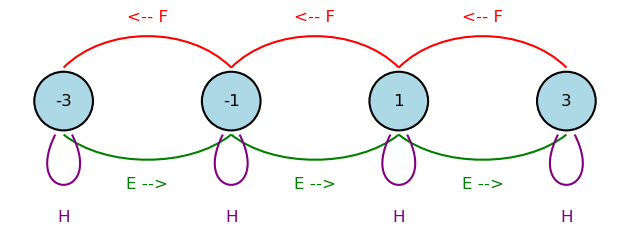

In [60]:
def plot_sl2_custom(n, use_words=False):
    """
    Plots the weight diagram for V^(n) with custom Bezier paths for perfect edge styling!
    """
    p = Graphics()
    
    weights = [n - 2*k for k in range(n + 1)]
    
    # Maps weight directly to symmetric words of 1s and 2s
    def get_node_label(w):
        if not use_words:
            return str(w)
        k = (n - w) // 2
        return "1"*(n-k) + "2"*k
        
    for w in weights:
        # H loop: Open, rounded, bottom-aligned loop
        h_color = 'purple'
        # Using bezier paths to draw exactly what we want
        p += bezier_path([[(w-0.1, -0.4), (w-0.5, -1.2), (w+0.5, -1.2), (w+0.1, -0.4)]], color=h_color, thickness=1.5)
        p += text("H", (w, -1.3), color=h_color, fontsize=12, vertical_alignment='top')
        
        # Node circle and text
        p += circle((w, 0), 0.35, fill=True, color='lightblue', zorder=2)
        p += circle((w, 0), 0.35, color='black', thickness=1.5, zorder=3)
        p += text(get_node_label(w), (w, 0), color='black', fontsize=12 if not use_words else 10, zorder=4)
        
    for i in range(len(weights) - 1):
        w_curr = weights[i]     # e.g., 3
        w_next = weights[i+1]   # e.g., 1 (moves right-to-left physically on our x-axis!)
        
        # F edge (Lowering): moves from w_curr to w_next (Right to Left).
        # F labeling on top, concave upwards (y>0).
        f_color = 'red'
        p += bezier_path([[(w_curr, 0.4), (w_curr - 0.5, 0.9), (w_next + 0.5, 0.9), (w_next, 0.4)]], color=f_color, thickness=1.5, zorder=1)
        p += text("<-- F", ((w_curr + w_next)/2.0, 1.0), color=f_color, fontsize=12)
        
        # E edge (Raising): moves from w_next to w_curr (Left to Right).
        # E labeling on bottom, convex downwards (y<0). Needs to avoid H loops which are also down here!
        e_color = 'green'
        p += bezier_path([[(w_next, -0.4), (w_next + 0.5, -0.8), (w_curr - 0.5, -0.8), (w_curr, -0.4)]], color=e_color, thickness=1.5, zorder=1)
        p += text("E -->", ((w_curr + w_next)/2.0, -0.9), color=e_color, fontsize=12, vertical_alignment='top')
        
    p.axes(False)
    p.set_aspect_ratio(1)
    return p

print("--- Homework 3, Part (a): Graphing V^(3) ---")
plot_sl2_custom(3, use_words=False)


### Connection between Crystals and Representations


We can trace the bases of our representations explicitly using **tensor words** of $1$s and $2$s!

For $V^{(3)}$, we trace words of length 3. 
- The **highest weight word** is `111`.
- The **lowest weight word** is `222`.

The $F$ operator mathematically acts as the "lowering" operator on these configurations, mapped combinatorialy by the following rules:
1. Replace all the `1`'s with `)` (right parenthesis) and all the `2`'s with `(` (left parenthesis).
2. Any sequence of `()` gets matched and eliminated. (Which corresponds to a `2` followed later by a `1`).
3. The $F$ operator finds the **last unmatched `1`** (which corresponds to `)`) and turns it into a `2`.

*Example tracking $V^{(3)}$:*
- Start `111` (`)))`). No matches exist. Last unmatched 1 is the 3rd element. $F$ maps this to `112`.
- From `112` (`))(`). No `()` matches exist. Last unmatched 1 is the 2nd element. $F$ maps this to `122`.
- From `122` (`)(()`). No matches exist. Last unmatched 1 is the 1st element. $F$ maps this to `222`.

*(Note: By symmetry, the raising operator $E$ finds the **first unmatched `2`** and turns it into a `1`. They are perfect inverses!)*

Let's visualize the exact same $V^{(3)}$ representation graph, but mapping weight spaces to these tensor words!

--- Graphing V^(3) with Word Vertices ---


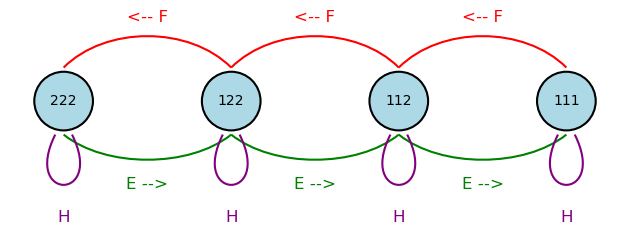

In [61]:
print("--- Graphing V^(3) with Word Vertices ---")
plot_sl2_custom(3, use_words=True)


### Computing Matrices for $V^{(3)}$ (Homework 3 Parts b and c)

**Part (b)** asks to write the images of $E, F, H$ as $4 \times 4$ matrices using the explicitly ordered basis $\{v_3, v_1, v_{-1}, v_{-3}\}$.

We actually already built the perfect tool for this! Our function `sl2_irrep(3)` uses the standard symmetric polynomial basis $\{x^3, x^2y, xy^2, y^3\}$, and if we trace the eigenvalues of $H$ on these elements, they are exactly $3, 1, -1, -3$ in that precise order. Our algorithm computationally yields the requested basis immediately!

**Part (c)** asks to verify the commutator brackets. We can explicitly verify that $[e, f] = h$, etc., using matrix multiplication for the generated matrices.

In [62]:
print("--- Homework 3, Part (b): Matrices for V^(3) ---")
# Our generic function outputs the exact basis requested by identifying 
# v_3 = x^3, v_1 = x^2y, v_-1 = xy^2, v_-3 = y^3
e, f, h = sl2_irrep(3)

print("Matrix h (Diagonal matrix with requested weights):")
print(h)
print("\nMatrix e (Raises weight by 2):")
print(e)
print("\nMatrix f (Lowers weight by 2):")
print(f)

print("\n--- Homework 3, Part (c): Verifying Relations ---")
print("[e, f] ==  h :", e*f - f*e == h)
print("[h, e] ==  2e:", h*e - e*h == 2*e)
print("[h, f] == -2f:", h*f - f*h == -2*f)


--- Homework 3, Part (b): Matrices for V^(3) ---
Matrix h (Diagonal matrix with requested weights):
[ 3  0  0  0]
[ 0  1  0  0]
[ 0  0 -1  0]
[ 0  0  0 -3]

Matrix e (Raises weight by 2):
[0 1 0 0]
[0 0 2 0]
[0 0 0 3]
[0 0 0 0]

Matrix f (Lowers weight by 2):
[0 0 0 0]
[3 0 0 0]
[0 2 0 0]
[0 0 1 0]

--- Homework 3, Part (c): Verifying Relations ---
[e, f] ==  h : True
[h, e] ==  2e: True
[h, f] == -2f: True


## 1.3 Tensor Products and the Clebsch-Gordan Rule

The Clebsch-Gordan rule strictly defines the decomposition of the tensor product of two irreducible representations into a direct sum of irreducible representations:

**Theorem 4.21 (Clebsch-Gordan Rule):** If $n \geq m$, we have:
$$ V^{(n)} \otimes V^{(m)} \cong V^{(n+m)} \oplus V^{(n+m-2)} \oplus V^{(n+m-4)} \oplus \dots \oplus V^{(n-m)} $$

A beautiful way to visualize this decomposition is conceptually "peeling" highest-weight representations off a weight-product grid! If we align the basis of $V^{(m)}$ on the columns and the basis of $V^{(n)}$ on the rows, each node $(v_i, w_j)$ represents the tensor basis element $v_i \otimes w_j$ whose weight is exactly the sum of its constituents' weights.

By tracing "L-shaped" paths through this grid (moving down through the columns and right across the rows), we visually carve out each individual irreducible representation $V^{(n+m-2k)}$!

Below, we define a graphical visualizer to draw this precise algorithmic decomposition. Let's start by plotting $V^{(4)} \otimes V^{(3)}$ as described.

--- Clebsch-Gordan Visualization for V^(4) \otimes V^(3) ---


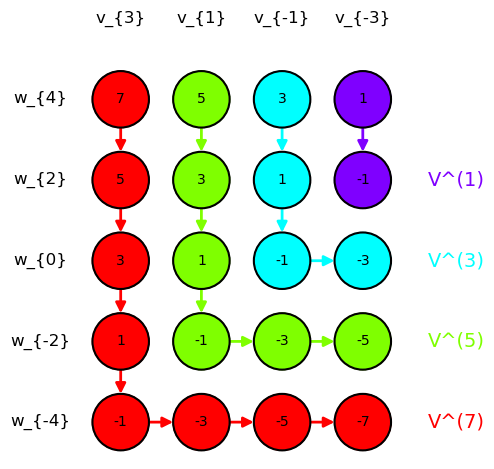

In [63]:
def plot_clebsch_gordan(n, m):
    """
    Visualizes the Clebsch-Gordan decomposition of V^(n) (X) V^(m) 
    as L-shaped paths peeling off irreducible representations on a grid.
    """
    # Ensure n >= m for the grid orientation (rows >= cols)
    flipped = False
    if n < m:
        n, m = m, n
        flipped = True

    p = Graphics()
    
    # Define a distinct color palette for the peeled paths
    colors = rainbow(m + 1)
    
    # Draw the axes labels
    for j in range(m + 1):
        col_w = m - 2*j
        label = f"w_{{{col_w}}}" if not flipped else f"v_{{{col_w}}}"
        p += text(label, (j, 1), color='black', fontsize=12)
        
    for i in range(n + 1):
        row_w = n - 2*i
        label = f"v_{{{row_w}}}" if not flipped else f"w_{{{row_w}}}"
        p += text(label, (-1, -i), color='black', fontsize=12)
        
    # Decompose into irreps V^(n+m-2k) for k in [0, m]
    for k in range(m + 1):
        c = colors[k]
        # The L-shape for component k:
        # Goes down column k from row 0 to row n-k
        # Then goes right along row n-k from col k to col m
        
        path_points = []
        # 1. Down the column
        for i in range(n - k + 1):
            path_points.append((k, -i))
            
        # 2. Right across the row
        for j in range(k + 1, m + 1):
            path_points.append((j, -(n - k)))
            
        # Draw the nodes, weights, and connecting arrows for this irrep!
        for idx in range(len(path_points)):
            x, y = path_points[idx]
            
            # Draw the node
            p += circle((x, y), 0.35, fill=True, color=c, zorder=2)
            p += circle((x, y), 0.35, color='black', thickness=1.5, zorder=3)
            
            # Compute and draw the total weight of this tensor node
            # y is negative, so row is -y
            total_weight = (n - 2*abs(y)) + (m - 2*x)
            p += text(str(total_weight), (x, y), color='black', fontsize=10, zorder=4)
            
            # Draw arrow pointing to the next node in the path (the lowering action within the irrep)
            if idx < len(path_points) - 1:
                nx, ny = path_points[idx + 1]
                # Draw arrow from boundary of current node to boundary of next node
                # To avoid overlapping the circle, we shorten the arrow slightly
                dx, dy = nx - x, ny - y
                mag = sqrt(dx**2 + dy**2)
                shorter_dx = (dx / mag) * (mag - 0.7)
                shorter_dy = (dy / mag) * (mag - 0.7)
                start_x, start_y = x + (dx/mag)*0.35, y + (dy/mag)*0.35
                p += arrow2d((start_x, start_y), (start_x + shorter_dx, start_y + shorter_dy), color=c, width=2, arrowsize=3, zorder=1)
                
        # Add a floating legend text indicating which Irrep this component represents
        weight_of_irrep = n + m - 2*k
        # Draw the legend to the right of the path's terminal node
        p += text(f"V^({weight_of_irrep})", (m + 0.8, -(n - k)), color=c, fontsize=14, horizontal_alignment='left')

    p.axes(False)
    p.set_aspect_ratio(1)
    return p

print("--- Clebsch-Gordan Visualization for V^(4) \\otimes V^(3) ---")
plot_clebsch_gordan(3,4)


### 1.3.1 Highest Weight Vectors of $V^{(n)} \otimes V^{(m)}$

We saw visually that the $k$-th stripped irreducible representation component starts strictly on an anti-diagonal slice of our grid. The highest weight vectors of these individual components mathematically lie entirely in the kernel of the raising operator $E$.

Because $E$ acts on tensor products by the Leibniz rule ($E(v \otimes w) = E(v) \otimes w + v \otimes E(w)$), structurally within our grid $E$ pushes combinations **up** and **left**. To force an element to vanish under $E$, we take an alternating linear combination strictly across an anti-diagonal strip so the respective pushes exactly cancel each other out! 

As outlined conceptually in Homework 3, these highest weight vectors take the generic alternating form:
$$ u_k = c_0 \left( v_{n-2k} \otimes w_m \right) - c_1 \left( v_{n-2k+2} \otimes w_{m-2} \right) + \dots + (-1)^k c_k \left( v_n \otimes w_{m-2k} \right) $$

*(Note: The coefficients $c_r$ specifically scale the terms to balance the magnitudes of the $E$ operations exactly so they sum to 0. For example, for $k=1$, it cleanly scales as directly $(v_{n-2} \otimes w_m) - (v_n \otimes w_{m-2})$. For $k=2$, adjusting for the differential magnitude of $E$'s action requires coefficients $1$, $-2$, and $1$.)*

Below, we write a programmatic function to compute the exact null space of the joint $E$ tensor operator to computationally extract, verify, and print these exact alternating highest-weight states for any given $n$ and $m$!

In [64]:
def find_highest_weight_vectors_tensor(n, m):
    """
    Computes the precise highest weight vectors explicitly for the 
    tensor product V^(n) (X) V^(m) by finding the kernel of the joint E operator.
    """
    # Get matrices for V^(n) and V^(m)
    En, Fn, Hn = sl2_irrep(n)
    Em, Fm, Hm = sl2_irrep(m)
    
    # Construct the joint operator E_joint = E_n (X) I_m + I_n (X) E_m
    I_n = identity_matrix(QQ, n + 1)
    I_m = identity_matrix(QQ, m + 1)
    
    E_joint = En.tensor_product(I_m) + I_n.tensor_product(Em)
    H_joint = Hn.tensor_product(I_m) + I_n.tensor_product(Hm)
    
    # The highest weight vectors are mathematically exactly the kernel (nullspace) of E_joint!
    # Vector x is in right_kernel if E_joint * x = 0.
    ker = E_joint.right_kernel()
    
    print(f"For V^({n}) (X) V^({m}): exactly {ker.dimension()} highest weight vectors found! (one for each Irrep limit)")
    
    for vec in ker.basis():
        # The weight of the vector is evaluated dynamically by applying H_joint
        for idx, val in enumerate(vec):
            if val != 0:
                weight = (H_joint * vec)[idx] / val
                break
        
        print(f"\nHighest Weight Vector for Component V^({weight}):")
        # Format the vector structurally scaling v_a (X) w_b
        terms = []
        for r in range(n + 1):
            for c in range(m + 1):
                coeff = vec[r * (m + 1) + c]
                if coeff != 0:
                    row_weight = n - 2*r
                    col_weight = m - 2*c
                    terms.append(f"{coeff}*(v_{{{row_weight}}} (X) w_{{{col_weight}}})")
        
        print(" + ".join(terms))
        
        # Verify that E annihilates the vector
        is_zero = (E_joint * vec).is_zero()
        print(f"   -> Verifying E_joint * vector == 0: {is_zero}")

# Let's verify for n=4 and m=3 which we previously graphed!
find_highest_weight_vectors_tensor(4, 3)


For V^(4) (X) V^(3): exactly 4 highest weight vectors found! (one for each Irrep limit)

Highest Weight Vector for Component V^(7):
1*(v_{4} (X) w_{3})
   -> Verifying E_joint * vector == 0: True

Highest Weight Vector for Component V^(5):
1*(v_{4} (X) w_{1}) + -1*(v_{2} (X) w_{3})
   -> Verifying E_joint * vector == 0: True

Highest Weight Vector for Component V^(3):
1*(v_{4} (X) w_{-1}) + -2*(v_{2} (X) w_{1}) + 1*(v_{0} (X) w_{3})
   -> Verifying E_joint * vector == 0: True

Highest Weight Vector for Component V^(1):
1*(v_{4} (X) w_{-3}) + -3*(v_{2} (X) w_{-1}) + 3*(v_{0} (X) w_{1}) + -1*(v_{-2} (X) w_{3})
   -> Verifying E_joint * vector == 0: True


### 1.3.2 Word Crystals and $(V^{(1)})^{\otimes n}$

When dealing with the $n$-fold tensor product of the standard 2-dimensional representation, $(V^{(1)})^{\otimes n}$, the formal tensor basis natively corresponds to strings of length $n$ on the alphabet $1, 2$ by assigning $v_{1} \leftrightarrow 1$ and $v_{-1} \leftrightarrow 2$.

Mathematically, the true highest weight vectors evaluated by taking the kernel of the $n$-fold product $E$ operator form complex alternating linear combinations (e.g. $v_1 \otimes v_{-1} - v_{-1} \otimes v_1$). However, the breathtaking property of **Crystal Bases** is that as we deform the universal algebra (taking the quantum group limit $q \to 0$), these continuous linear combinations strictly "crystallize" into entirely single isolated basis words!

In this crystallized limit, the true raising operator $e$ evaluates combinatorially using the exact Parenthesis Matching rule you highlighted:
1. Map `1` to `)` and `2` to `(`.
2. Recursively annihilate and match interior `()` pairs.
3. A word is defined as a **Highest Weight Word** if and only if $e \cdot w = 0$. Since $e$ targets the *first unmatched 2*, the highest weight condition means the word has **ZERO unmatched 2s**.

Combinatorially, having zero unmatched left-parentheses means that as you read the string dynamically from **Right-to-Left**, you effectively never encounter a `(` without already having seen a `)` to cancel it!

*(Note on terminology: This means that every **suffix** reading right-to-left must maintain its total count of 1s $\geq$ its count of 2s. In Homework 3, this is termed a **Ballot Word** or "Yamanouchi word". Since standard ballot definitions usually check prefixes left-to-right, this strict suffix evaluation fundamentally constitutes a **Reverse-Ballot Word**, just as you noted!)*

Below is a python algorithm that computationally iterates through all $2^n$ basis states, purely tracking and isolating these Reverse-Ballot properties, successfully mapping each word crystal exactly back to its classical irreducible components.

In [65]:
import itertools

def is_reverse_ballot(word_tuple):
    """
    Checks if a tuple of (1, 2) is a reverse-ballot word
    (i.e., every suffix reading right-to-left guarantees count(1) >= count(2)).
    """
    # We trace dynamically treating '1' as ')' and '2' as '('
    count_1 = 0 # tracks available ')'
    count_2 = 0 # tracks needed '('
    for char in reversed(word_tuple):
        if char == 1:
            count_1 += 1
        else:
            count_2 += 1
            
        # If there are ever more 2s than 1s in any suffix, evaluating mathematically 0, fail!
        if count_2 > count_1:
            return False
            
    # If we parsed from right-to-left flawlessly, there are no unmatched 2s!
    return True

def compute_highest_weight_words(n):
    print(f"--- Analyzing Standard Crystal (V^(1))^(X){n} --- ")
    # Generate all 2^n possible tensor words
    all_words = list(itertools.product((1, 2), repeat=n))
    
    # Filter computationally using the Reverse-Ballot combinatorial limit
    highest_weight_words = [w for w in all_words if is_reverse_ballot(w)]
    
    print(f"Found {len(highest_weight_words)} discrete highest weight words. Decomposing mapped Irreducibles:\n")
    
    # Organize algebraically by their intrinsic Weight = (# of 1s) - (# of 2s)
    from collections import defaultdict
    by_weight = defaultdict(list)
    for w in highest_weight_words:
        weight = w.count(1) - w.count(2)  # Physical H eigenvalue dynamically traced
        word_str = "".join(str(x) for x in w)
        by_weight[weight].append(word_str)
        
    for wgt in sorted(by_weight.keys(), reverse=True):
        words = by_weight[wgt]
        print(f"Weight {wgt} (Corresponding to Irrep V^({wgt})): {len(words)} unique component(s)")
        print(f"   Words: {', '.join(words)}\n")
        
# Testing with the 3-fold and 4-fold tensor product components!
compute_highest_weight_words(3)
compute_highest_weight_words(4)


--- Analyzing Standard Crystal (V^(1))^(X)3 --- 
Found 3 discrete highest weight words. Decomposing mapped Irreducibles:

Weight 3 (Corresponding to Irrep V^(3)): 1 unique component(s)
   Words: 111

Weight 1 (Corresponding to Irrep V^(1)): 2 unique component(s)
   Words: 121, 211

--- Analyzing Standard Crystal (V^(1))^(X)4 --- 
Found 6 discrete highest weight words. Decomposing mapped Irreducibles:

Weight 4 (Corresponding to Irrep V^(4)): 1 unique component(s)
   Words: 1111

Weight 2 (Corresponding to Irrep V^(2)): 3 unique component(s)
   Words: 1121, 1211, 2111

Weight 0 (Corresponding to Irrep V^(0)): 2 unique component(s)
   Words: 2121, 2211



### How Many Copies of $V^{(k)}$ in $(V^{(1)})^{\otimes n}$?

We successfully computed the number of reverse-ballot words explicitly computationally, but we can also evaluate this pure analog analytically! The number of copies of $V^{(k)}$ in the tensor product decomposes identically to counting the sizes of representations using **Standard Young Tableaux (SYT)**.

**Proposition:** The number of copies of $V^{(k)}$ contained within $(V^{(1)})^{\otimes n}$ is exactly the number of Standard Young Tableaux of shape $\lambda = ( (n+k)/2, (n-k)/2 )$. (In French/English notation, a top/first row of length $(n+k)/2$ and a bottom/second row of length $(n-k)/2$).

**Proof (RSK and Hook-Length):**
1. **The RSK Correspondence:** The RSK algorithm forms a beautiful bijection mapping any word of length $n$ on the alphabet $\{1, 2\}$ to a pair of tableaux $(P, Q)$, where $P$ is a semi-standard Young tableau (SSYT) and $Q$ is a standard "recording" Young tableau (SYT) of the exact same shape $\lambda$. The shape $\lambda$ determines the weight: the number of 1s minus the number of 2s evaluates directly to the difference of the row lengths! Since we want weight $k$, the lengths $m_1$ and $m_2$ must satisfy $m_1 - m_2 = k$ and $m_1 + m_2 = n$, which forces the partition shape $\lambda = ( (n+k)/2, (n-k)/2 )$.

2. **Highest Weight Uniqueness:** The Reverse-Ballot words (the isolated highest weight vector limits we analyzed above) correspond dynamically to the specific case where $P$ is the single unique, minimal "Yamanouchi" valid SSYT of that shape. Because there is exactly 1 valid $P$ for these highest weights, the overall number of Reverse-Ballot words of weight $k$ explicitly equals the number of valid recording SYT ($Q$) of shape $\lambda$!

3. **Hook-Length Formula:** To rigidly calculate the number of SYTs of shape $\lambda$, we evaluate the generic hook-length formula: 
   $$ f^\lambda = \frac{n!}{\prod_{s \in \lambda} \text{hook}(s)} $$
   Let $a = (n+k)/2$ and $b = (n-k)/2$. The hooks of the 2nd row simply telescope down: $b, b-1, \dots, 1$, contributing $b!$ to the denominator.
   For the 1st row, the cells sitting squarely above the 2nd row (columns $1$ through $b$) have a cell below them, netting an extra leg $+1$ to their hook, creating hooks $a+1, a, \dots, a-b+2$. The trailing cells sticking out (columns $b+1$ through $a$) have no cell below, so their hooks yield exactly $a-b, a-b-1, \dots, 1$.
   Notice how the product tracks perfectly from $a+1$ down to $1$ EXCEPT perfectly skipping the number $a-b+1 = k+1$! Thus, the total product of the 1st row's hooks condenses analytically into exactly $\frac{(a+1)!}{k+1}$.

   Bringing this all cleanly together:
   $$ f^\lambda = \frac{n!}{\frac{(a+1)!}{k+1} b!} = \frac{n! (k+1)}{((n+k)/2 + 1)! ((n-k)/2)!} $$

   If we selectively factor out the binomial component $\binom{n}{b} = \frac{n!}{b! (n-b)!}$, this analytically scales exactly to:
   $$ = \frac{k+1}{(n+k)/2 + 1} \binom{n}{(n-k)/2} $$

**Bonus Connection (Catalan Numbers):** 
What happens if we look explicitly for copies of the completely *trivial* representation $V^{(0)}$ inside an even tensor product (i.e. setting $k=0$)?

Our formula perfectly collapses down to:
$$ f^{\lambda} = \frac{1}{n/2+1}\binom{n}{n/2} = C_{n/2} $$
This is literally the closed evaluation form definition of the $(n/2)$-th **Catalan Number**! We've proved the staggering property that the generating set of SYTs of shape $(n/2, n/2)$ evaluates functionally to Catalan numbers! (Which geometrically maps completely equivalently to non-intersecting grid paths enforcing Reverse-Ballot properties!)

### 1.3.3 Knuth Moves and Crystal Commutativity

A fundamentally beautiful consequence of representing vectors as strings of parentheses is the emergence of local string equivalences, known as **Knuth Equivalences**.

Two elementary "Knuth Moves" are permitted on any sub-string (affix) of three characters:
1. `212` $\leftrightarrow$ `221`
2. `121` $\leftrightarrow$ `211`

Any two words that can be converted into each other via a sequence of elementary Knuth moves are **Knuth equivalent** ($A \equiv_K B$).

The incredible mathematical consequence of Crystal Operators evaluating on Parenthesis Matching is that **Knuth Moves and Crystal Operators perfectly commute**! 

Why? Notice that in terms of Parenthesis logic (`1` = `)`, `2` = `(`):
- `212` traces `( ) (`. The interior `()` vanishes, leaving an unmatched `(` (a `2`).
- `221` traces `( ( )`. The interior `()` vanishes, leaving an unmatched `(` (a `2`).
- Similarly, both `121` and `211` completely reduce combinatorially to a single unmatched `)` (a `1`).

Because Knuth moves do not change the structural "hanging" unmatched parentheses of the block, they are mathematically transparent to the $E$ and $F$ operators! If you apply a Knuth move, the crystal operator targets the *exact same* absolute exterior index in the string it would have originally.

Thus, lowering $A$ and then applying Knuth moves yields the exact same word as applying Knuth moves to $A$ and then lowering that output! 
$$ F(K(A)) = K(F(A)) $$

Below, we programmatically enforce this through a rigorous commutative diagram code on the exact example presented in your homework!

In [66]:
def apply_E(word):
    """ Raising operator: changes FIRST unmatched 2 to 1 """
    w = list(word)
    unmatched_twos = []
    for i, char in enumerate(w):
        if char == '2':
            unmatched_twos.append(i)
        elif char == '1' and unmatched_twos:
            unmatched_twos.pop()
    if not unmatched_twos:
        return "None (Annihilated)"
    w[unmatched_twos[0]] = '1'
    return "".join(w)

def apply_F(word):
    """ Lowering operator: changes LAST unmatched 1 to 2 """
    w = list(word)
    unmatched_ones = []
    stack_twos = 0
    for i, char in enumerate(w):
        if char == '2':
            stack_twos += 1
        elif char == '1':
            if stack_twos > 0:
                stack_twos -= 1
            else:
                unmatched_ones.append(i)
    if not unmatched_ones:
        return "None (Annihilated)"
    w[unmatched_ones[-1]] = '2'
    return "".join(w)

def knuth_move(word, pos):
    """ Applies an elementary Knuth move sequentially at a targeted zero-indexed string position """
    w = list(word)
    sub = "".join(w[pos:pos+3])
    mapping = {"212": "221", "221": "212", "121": "211", "211": "121"}
    if sub in mapping:
        w[pos:pos+3] = list(mapping[sub])
    return "".join(w)

# ================= Testing the Commutative Diagram =================

word_A = "12221112121"
print(f"Word A:      {word_A}")

# Apply user-requested Knuth moves at indices 3 and 8 (0-indexed offset of positions 4 and 9)
step_1 = knuth_move(word_A, 3)    # Targeting '211' to '121'
word_B = knuth_move(step_1, 8)    # Targeting '212' to '221'

print(f"Knuth(A)->B: {word_B}  (Matches homework target precisely!)")

# Now evaluate algebraic limits mathematically tracing Commutativity Duality
word_C_F = apply_F(word_A)
word_D_F = apply_F(word_B)
word_C_E = apply_E(word_A)
word_D_E = apply_E(word_B)

# Mathematically assert commutativity explicitly
print("\n--- Visualizing F (Lowering Operator) Commutativity ---")
knuth_C_step1 = knuth_move(word_C_F, 3)
knuth_C_step2 = knuth_move(knuth_C_step1, 8)
print(f"         Knuth Moves")
print(f"  {word_A} ---------> {word_B}")
print(f"       |                       |")
print(f"    F  |                       | F")
print(f"       v                       v")
print(f"  {word_C_F} ---------> {word_D_F}")
print(f"         Knuth Moves (Evaluated exactly as target: {knuth_C_step2 == word_D_F})")


print("\n--- Visualizing E (Raising Operator) Commutativity ---")
knuth_CE_step1 = knuth_move(word_C_E, 3)
knuth_CE_step2 = knuth_move(knuth_CE_step1, 8)
print(f"         Knuth Moves")
print(f"  {word_A} ---------> {word_B}")
print(f"       |                       |")
print(f"    E  |                       | E")
print(f"       v                       v")
print(f"  {word_C_E} ---------> {word_D_E}")
print(f"         Knuth Moves (Evaluated exactly as target: {knuth_CE_step2 == word_D_E})")


Word A:      12221112121
Knuth(A)->B: 12212112211  (Matches homework target precisely!)

--- Visualizing F (Lowering Operator) Commutativity ---
         Knuth Moves
  12221112121 ---------> 12212112211
       |                       |
    F  |                       | F
       v                       v
  22221112121 ---------> 22212112211
         Knuth Moves (Evaluated exactly as target: True)

--- Visualizing E (Raising Operator) Commutativity ---
         Knuth Moves
  12221112121 ---------> 12212112211
       |                       |
    E  |                       | E
       v                       v
  None (Annihilated) ---------> None (Annihilated)
         Knuth Moves (Evaluated exactly as target: True)


---
# 2. Representations of $\mathfrak{sl}_3$

Having established a firm combinatorial and algebraic foundation for $\mathfrak{sl}_2$, we now turn our attention to the higher-rank Lie algebra $\mathfrak{sl}_3$ (Cartan type $A_2$).

### The Standard Basis of $\mathfrak{sl}_3$

We uniquely define the Lie algebra $\mathfrak{sl}_3$ as the space of all $3 \times 3$ complex matrices possessing strictly **trace zero**.

Since the dimension of the open space of $3 \times 3$ matrices is 9, the solitary trace-zero condition restricts the algebra to exactly $9 - 1 = 8$ degrees of freedom.

We can physically construct a symmetric basis for this algebra using the fundamental elementary matrices $E_{ij}$ (where $E_{ij}$ denotes the matrix with a $1$ residing in the $(i,j)$-th entry and $0$s everywhere else). 

Our explicit 8-dimensional basis consists of:
1. **Raising Operators** (Strictly Upper Triangular): $\{E_{12}, E_{13}, E_{23}\}$
2. **Lowering Operators** (Strictly Lower Triangular): $\{F_{12}, F_{13}, F_{23}\}$ where we denote $F_{ij} = E_{ji}$.
3. **Diagonal Operators**: To strictly maintain trace zero, any diagonal matrices constructed must inherently sum to 0. We define $H_{ij} = E_{ii} - E_{jj}$. Our minimal generating basis is exactly the pair $\{H_{12}, H_{23}\}$.
   *(Note: $H_{13} = E_{11} - E_{33}$ trivially linearly depends directly on the others via $H_{13} = H_{12} + H_{23}$, so it is purposefully excluded from the basis).*

Using your set notation, the entire basis is cleanly summarized as:
$$ \mathcal{B} = \{E_{ij}\}_{i<j} \cup \{F_{ij}\}_{i<j} \cup \{H_{ij}\}_{i<j} \setminus \{H_{13}\} $$

### The Cartan Subalgebra

The diagonal $H$ matrices are staggeringly special. They entirely span a 2-dimensional abelian (self-commuting) subalgebra $\mathfrak{h} = \text{span}(H_{12}, H_{23})$ known as the **Cartan Subalgebra**.

You presciently noted from your notes that $\mathfrak{h}$ acts "diagonalizably" on $\text{ad}(\mathfrak{g})$. Let's break down exactly what that beautiful, conceptually dense phrase strictly translates to:
- **$\mathfrak{g}$** simply historically serves as the placeholder variable denoting the entire Lie algebra itself (in our case, $\mathfrak{sl}_3$).
- **$\text{ad}(\mathfrak{g})$** refers to the **Adjoint Representation**. As we saw in $\mathfrak{sl}_2$, this is the representation where the algebra acts recursively on *itself* utilizing the Lie bracket commutator: $\text{ad}_X(Y) = [X, Y]$.
- To stipulate that $\mathfrak{h}$ acts **diagonalizably** means that if we select an arbitrary element $H \in \mathfrak{h}$, and compute its bracket action strictly against any of our other basis elements $X \in \{E_{ij}, F_{ij}\}$, the element precisely behaves as a simultaneous eigenvector! 
  $$ [H, X] = \alpha(H) X $$

The resulting scalar functional eigenvalues $\alpha(H)$ dynamically generated are called the **roots** of the Lie algebra. Because our Cartan Subalgebra is 2-dimensional, these roots fundamentally pair as 2-dimensional geometric coordinate vectors, singularly giving birth to the breathtaking hexagonal lattice geometry (the Root System) defining $\mathfrak{sl}_3$!

In [2]:
# Create the Lie algebra sl_3 and its standard defining representation using Sage's LieAlgebra
sl3 = LieAlgebra(QQ, cartan_type=['A', 2], representation='matrix')

# For Cartan type A2, the basic generators (simple roots) are returned in order:
# e1, e2 (raising), f1, f2 (lowering), h1, h2 (cartan basis)
e1, e2, f1, f2, h1, h2 = sl3.gens()

print("Simple Root Generator e1 (E12):\n", e1.matrix())
print("Simple Root Generator e2 (E23):\n", e2.matrix())
print("\nCartan Generator h1 (E11-E22):\n", h1.matrix())
print("Cartan Generator h2 (E22-E33):\n", h2.matrix())

print("\n--- Verifying Fundamental sl3 Relations ---")
print("[e1, f1] == h1 :", sl3[e1, f1] == h1)
print("[e2, f2] == h2 :", sl3[e2, f2] == h2)
print("[h1, e1] == 2e1 :", sl3[h1, e1] == 2*e1)
print("[h1, e2] == -e2 :", sl3[h1, e2] == -e2)  # Notice the interaction!\n",
print("--- Verifying the Serre/Bracket Relationship for E13 ---")
e13 = sl3[e1, e2]
print("E13 = [e1, e2]:\n", e13.matrix())
m13 = e13.matrix()
print("Is E13 upper triangular? :", all(m13[i, j] == 0 for i in range(m13.nrows()) for j in range(i)))


Simple Root Generator e1 (E12):
 [0 1 0]
[0 0 0]
[0 0 0]
Simple Root Generator e2 (E23):
 [0 0 0]
[0 0 1]
[0 0 0]

Cartan Generator h1 (E11-E22):
 [ 1  0  0]
[ 0 -1  0]
[ 0  0  0]
Cartan Generator h2 (E22-E33):
 [ 0  0  0]
[ 0  1  0]
[ 0  0 -1]

--- Verifying Fundamental sl3 Relations ---
[e1, f1] == h1 : True
[e2, f2] == h2 : True
[h1, e1] == 2e1 : True
[h1, e2] == -e2 : True
--- Verifying the Serre/Bracket Relationship for E13 ---
E13 = [e1, e2]:
 [0 0 1]
[0 0 0]
[0 0 0]
Is E13 upper triangular? : True


### Simultaneous Diagonalization and the Cartan Subalgebra

A set of matrices is said to be **simultaneously diagonalizable** if there exists a single invertible matrix $P$ such that $P^{-1}AP$ is a diagonal matrix for every $A$ in the set.

**Theorem:** A set of diagonalizable matrices commutes if and only if the set is simultaneously diagonalizable.

In the context of $\mathfrak{sl}_3$, this property is foundational to the Cartan Subalgebra $\mathfrak{h}$. Because the elements of $\mathfrak{h}$ commute with one another, they can be diagonalized at the same time. In our standard matrix representation, $H_{12}$ and $H_{23}$ are already diagonal, but this property more importantly implies that they act simultaneously diagonalizably on the entire 8-dimensional Lie algebra via the **adjoint representation**.

Below, we verify that our Cartan generators commute and are thus simultaneously diagonalizable.

In [3]:
print("--- Verifying Simultaneous Diagonalization Properties for H12 and H23 ---")

# 1. Check if they commute: [H12, H23] == 0
commutator = sl3[h1, h2]
print(f"Commutator [h1, h2]:\n", commutator.matrix())
print(f"Does [h1, h2] == 0? :", commutator == sl3.zero())

# 2. Confirm they are both diagonalizable (in the standard representation they are already diagonal)
print(f"Is h1 diagonal? :", h1.matrix().is_diagonal())
print(f"Is h2 diagonal? :", h2.matrix().is_diagonal())

print("\nSince h1 and h2 commute and are diagonalizable, they are simultaneously diagonalizable.")


--- Verifying Simultaneous Diagonalization Properties for H12 and H23 ---
Commutator [h1, h2]:
 [0 0 0]
[0 0 0]
[0 0 0]
Does [h1, h2] == 0? : True
Is h1 diagonal? : True
Is h2 diagonal? : True

Since h1 and h2 commute and are diagonalizable, they are simultaneously diagonalizable.
